### Loading data

In [127]:
import pandas as pd

train = pd.read_csv('./data/training_set.csv')
test = pd.read_csv('./data/test_set.csv')
validation = pd.read_csv('./data/validation_set.csv')

In [2]:
train

,feature1,feature2,feature3,feature4,feature5,Authenticated
0,0.599758,0.012166,0.209270,1.087926,4.088241,0
1,-5.512324,-0.426576,-0.092336,0.501431,3.844389,0
2,-3.387749,2.786477,0.195597,1.540859,4.148680,0
3,-4.690195,-1.024081,-0.101571,0.981619,3.712296,0
4,7.990252,0.398343,-0.302286,1.309536,3.870292,0
...,...,...,...,...,...,...
495,2.692383,-1.315251,0.544614,1.033572,3.509521,0
496,-2.109952,4.009235,0.160048,1.015621,3.559968,0
497,6.081859,-0.425740,0.045147,0.416322,4.223411,0
498,3.562751,5.979981,0.070664,1.481012,4.268754,0


In [3]:
test

,feature1,feature2,feature3,feature4,feature5
0,5.602877,-0.724157,-0.228973,0.309387,3.572336
1,3.948972,6.333084,-0.645195,1.104413,3.495307
2,1.294822,6.687754,-0.150185,1.116736,3.924246
3,-3.724215,1.246092,0.257122,0.912077,4.276480
4,1.800378,5.293923,0.092325,0.771986,4.569032
...,...,...,...,...,...
495,9.303078,2.246929,0.076717,0.995508,3.780451
496,7.316940,0.663353,0.037494,0.996475,4.146984
497,-5.403516,-1.286676,0.047576,1.420535,4.185733
498,0.453909,5.607141,0.039254,0.796912,3.908052


In [128]:
validation

,feature1,feature2,feature3,feature4,feature5
0,4.891380,-1.634033,-0.035535,1.071163,3.988173
1,2.216963,-2.196205,-0.179191,0.693892,4.056368
2,11.918513,4.170174,-0.355633,0.670830,3.689263
3,-1.692621,4.376455,0.092093,1.102890,4.254179
4,3.155467,-1.258807,0.062274,0.451649,3.392933
...,...,...,...,...,...
495,3.575572,6.526766,-0.101774,0.836010,3.619098
496,0.607154,4.898350,-0.440986,0.661599,3.979852
497,3.506191,6.788203,0.232107,1.007477,4.101855
498,6.652768,4.697454,-0.075333,0.994813,3.787809


### Analyzing data

Let's take a look at the label count of the training set

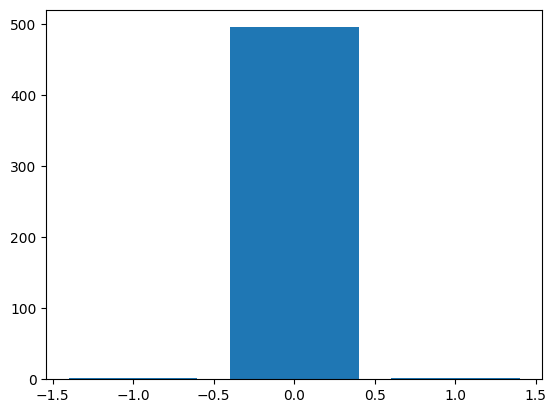

In [16]:
import matplotlib.pyplot as plt
import numpy as np

unique_values, counts = np.unique(np.array(train['Authenticated']), return_counts=True)

plt.bar(unique_values, counts)
plt.show()

In [20]:
dict(zip(unique_values, counts))

{-1: 2, 0: 496, 1: 2}

Unexpected. Apparently, there are only 4 labeled samples. 2 of each class.

Let's try reducing the dimensionality with t-SNE (since UMAP is not allowed in the competition) and plotting the data to see if we can spot anything.

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE()

tsne_data = tsne.fit_transform(train.drop('Authenticated', axis=1))

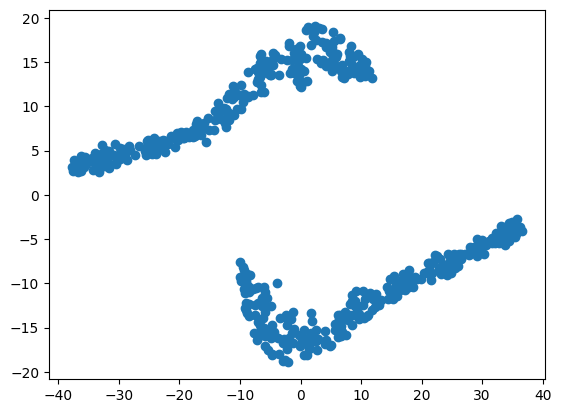

In [38]:
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])

Great, that's a clear pattern, those huge clusters must be the labels. Now it becomes trivial.

Let's start by using a clustering algorithm, spectral in this case, to separate the clusters.

In [47]:
from sklearn.cluster import SpectralClustering

model = SpectralClustering(n_clusters=2, random_state=42)
labels = model.fit_predict(tsne_data)

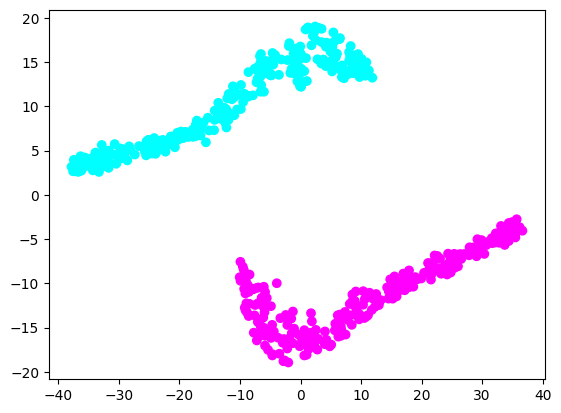

In [59]:
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=labels, cmap='cool')
plt.show()

Awesome, now our clusters are labeled. Now, we figure out which one is -1 and 1 according to what the problem asks us. For that, we'll look at the positions of the original 4 labels we are given.

In [94]:
df_labeled = train[train['Authenticated'] != 0]
original_label_indexes = df_labeled.index
original_labels = df_labeled['Authenticated']
tsne_data_original_labeled = tsne_data[original_label_indexes]

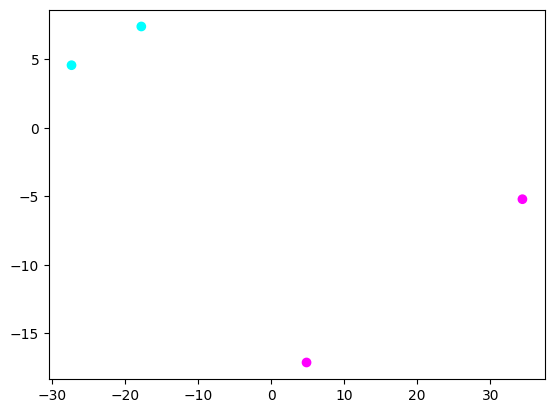

In [95]:
plt.scatter(tsne_data_original_labeled[:, 0], tsne_data_original_labeled[:, 1], c=original_labels, cmap='cool')
plt.show()

As suspected, two of the dots are in the upper cluster, and two in the lower one.

In [97]:
tsne_data_original_labeled, original_labels

(array([[-17.81024  ,   7.380898 ],
        [  4.8312926, -17.11648  ],
        [ 34.414    ,  -5.211728 ],
        [-27.373362 ,   4.557313 ]], dtype=float32),
 46    -1
 141    1
 182    1
 379   -1
 Name: Authenticated, dtype: int64)

With everything confirmed, let's just get the label our spectral clustering algorithm gave to the first labeled point, which is originally -1, and just replace everything else for that. Then, do the same for the other cluster, just with 1 instead.

In [109]:
labels[original_label_indexes[0]]

0

It's zero, so let's replace 0's for -1's, and keep 1's as they are.

In [115]:
final_labels = np.where(labels == 0, -1, 1)

final_labels

array([ 1, -1, -1, -1,  1,  1, -1, -1, -1, -1,  1, -1, -1,  1, -1,  1,  1,
       -1,  1,  1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,
        1, -1,  1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1, -1, -1,  1,  1,
        1, -1,  1, -1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1,
       -1, -1,  1, -1,  1,  1, -1, -1, -1,  1,  1, -1,  1, -1,  1,  1, -1,
        1, -1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1, -1, -1, -1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1,
       -1, -1, -1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1,  1,  1,  1, -1,
        1, -1,  1, -1,  1,  1, -1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1,
        1,  1, -1,  1,  1, -1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1,
       -1,  1, -1, -1,  1, -1, -1, -1, -1, -1,  1,  1,  1, -1,  1, -1, -1,
        1, -1,  1,  1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,
       -1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1, -1,
        1,  1,  1, -1,  1

In [ ]:
train_labeled = train.copy()
train_labeled['Authenticated'] = final_labels

train_labeled

,feature1,feature2,feature3,feature4,feature5,Authenticated
0,0.599758,0.012166,0.209270,1.087926,4.088241,1
1,-5.512324,-0.426576,-0.092336,0.501431,3.844389,-1
2,-3.387749,2.786477,0.195597,1.540859,4.148680,-1
3,-4.690195,-1.024081,-0.101571,0.981619,3.712296,-1
4,7.990252,0.398343,-0.302286,1.309536,3.870292,1
...,...,...,...,...,...,...
495,2.692383,-1.315251,0.544614,1.033572,3.509521,1
496,-2.109952,4.009235,0.160048,1.015621,3.559968,-1
497,6.081859,-0.425740,0.045147,0.416322,4.223411,1
498,3.562751,5.979981,0.070664,1.481012,4.268754,-1


### Training the model

With all the labeled labels, this becomes a trivial binary classification model. I'll be using a SVC for this one.

In [124]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(train_labeled.drop('Authenticated', axis=1), train_labeled['Authenticated'])

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Predicting the test 

Now we use the SVC trained on the training set to predict the test and validation set.

In [130]:
test_predictions = svc.predict(test)
validation_predictions = svc.predict(validation)

### Checking results

We'll also predict check the results for the validation set here. The `metrics.py` script is an adaptation of the one used in the real competition to work here.

In [131]:
from metrics import get_accuracy_test_set, get_accuracy_validation_set

print(f'Test score: {get_accuracy_test_set(test_predictions)}')
print(f'Val. score: {get_accuracy_validation_set(validation_predictions)}')

Test score: 0.98
Val. score: 0.984


We got 98% for both! That's about the best one can do.